## Notebook Workflow

1. Configure imports and paths for stage-04 odds-ratio analysis.
2. Run duplication and loss odds-ratio permulation tests.
3. Inspect confidence intervals, hit sets, and result summaries.
4. Export outputs for downstream enrichment and figure generation.

In [2]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Test for differences in odds of gene loss or duplication between orb-weavers and non-orb-weavers

98 species total, 41 foreground, 57 background
Log odds ratios of LOSS: 
 Mean: -0.50, Stddev: 1.53, Count of HOGs: 8291
Log odds ratios of DUPLICATION: 
 Mean: 0.03, Stddev: 1.11, Count of HOGs: 12096

LAUNCHING PERMULATION TEST

** Maximum occupancy set to 88 for loss test **
** Minimum occupancy set to 30 **

Using 10000 permulation-derived foreground/background assignments.


100%|██████████| 10000/10000 [04:57<00:00, 33.57it/s]


Permulation counter for MEANS:
 Loss: 1439, Duplication: 3778
*********************** RESULTS ***********************

Permulation test with 10000 repetitions
Minimum occupancy: 30; max occupancy (loss): 88
Analysis run on 2026-07-22 at 15:32:23
Foreground list: /Users/calvin/orb-selection/data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/data/N5.tsv
Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 8291 (loss), 12096 (duplication)
Total species: 98
Foreground count: 41
Background count: 57
True mean, loss: -0.503
True standard deviation, loss: 1.529
True mean, duplication: 0.035
True standard deviation, duplication: 1.111

** Permulation P-VALUES ** 

Probability that the null is true for MEAN, loss (alt=less): 0.144
Probability that the null is true for MEAN, duplication (alt=greater): 0.378

Permulated average mean, loss: -0.027
Permulated average s

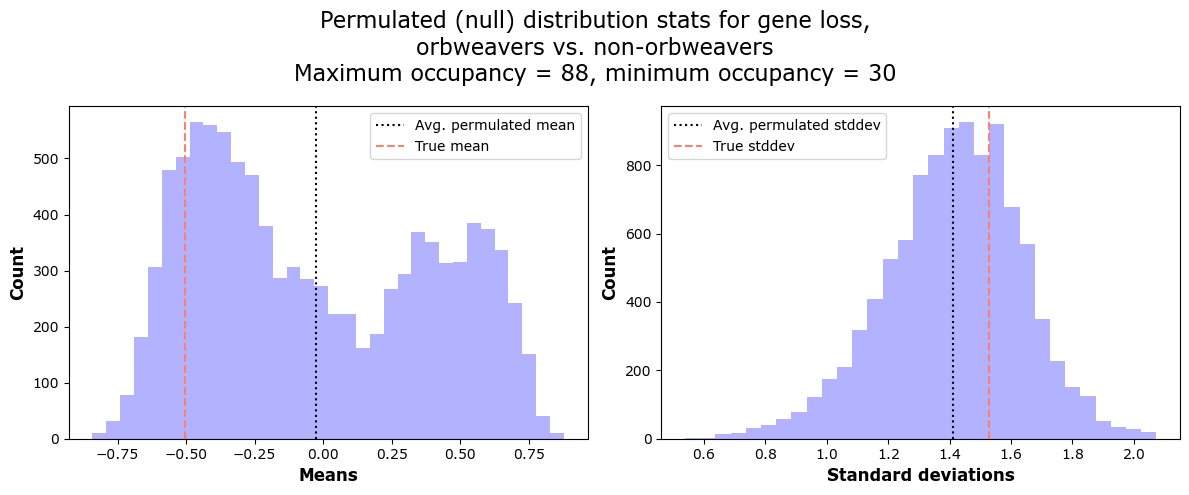

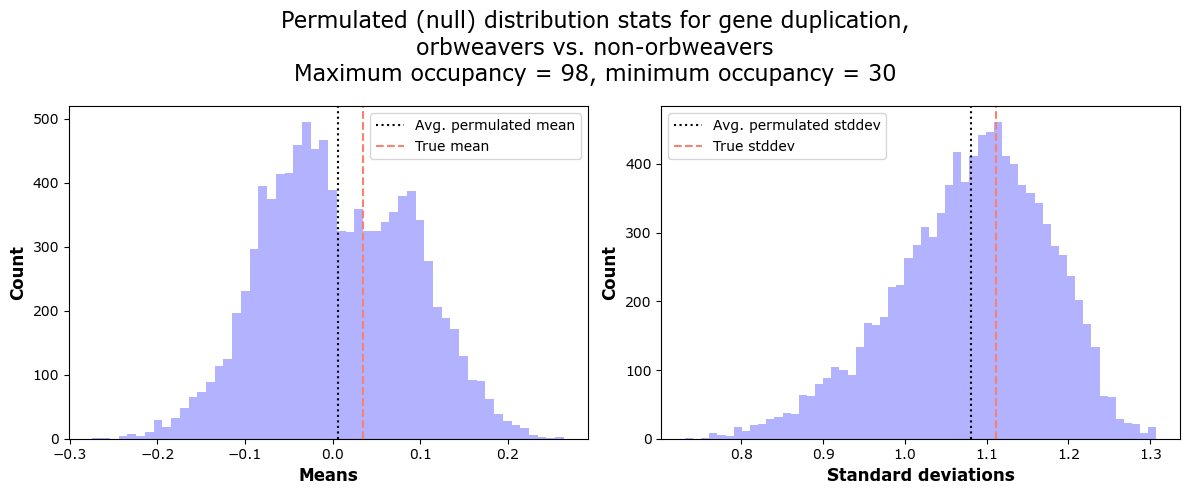

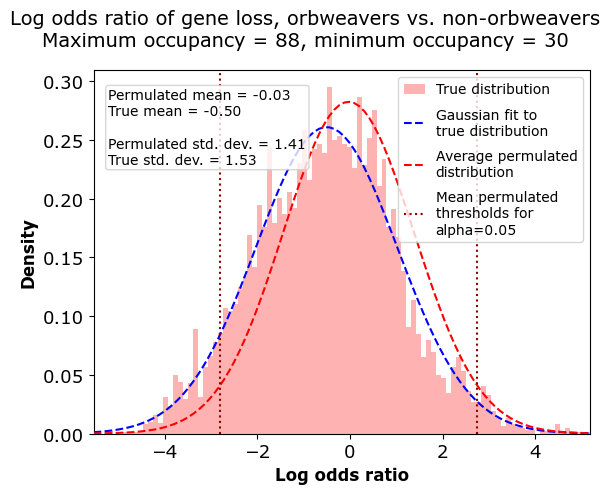

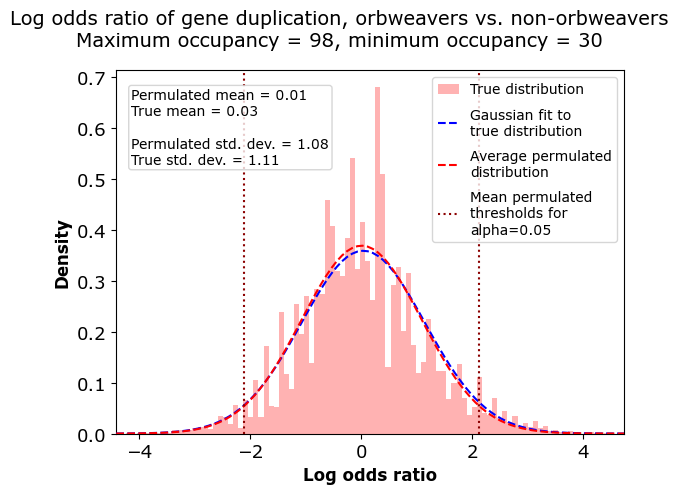

In [3]:
%autoreload 2
test = ort.odds_ratio_test(
    min_occ=30,
    max_occ=88,
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
)

In [5]:
%autoreload 2
results_all = ort.PermulationTestResults.load_from_pickle("results/odds_ratio_test/Results_Jul22/Run1_occ_30-88_10000x/results.pkl")
_, counts1, run1_df, total_count1 = results_all.filter_for_permulation_hits()
run1_df.head()

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001041,46,2.5214778926244144,-0.1557677830129427,0.0009,0.9991,0.4798,0.5202,,loss_fg
N5.HOG0001627,33,1.8558308507862529,-3.8579107827563353,0.064,0.936,0.9873,0.0127,dup_bg,dup_bg
N5.HOG0002031,46,-3.395453002905845,1.3321640223622708,0.9984,0.0016,0.412,0.588,loss_bg,loss_bg
N5.HOG0002072,52,3.079265415475248,-0.6393145308423711,0.0143,0.9857,0.8034,0.1964,loss_fg,loss_fg
N5.HOG0002076,55,-2.0505429717328014,0.7253857125250878,0.9545,0.0455,0.1584,0.8416,,loss_bg


### Save lists of all p-values

In [6]:
dup_res = results_all.results_df[results_all.results_df["Occupancy"]>=30][["Occupancy", "Log odds ratio of duplication", "P-value duplication more likely in fg", "P-value duplication more likely in bg"]]
dup_res.rename(columns={"Log odds ratio of duplication": "LOR",
                   "P-value duplication more likely in fg": "pval_fg",
                   "P-value duplication more likely in bg": "pval_bg"}, inplace=True)
dup_res

,Occupancy,LOR,pval_fg,pval_bg
HOG,,,,
N5.HOG0000042,30,0.945215,0.2944,0.7055
N5.HOG0000052,30,0.368290,0.1910,0.8090
N5.HOG0000147,34,0.818638,0.2451,0.7549
N5.HOG0000196,46,1.437307,0.1229,0.8771
N5.HOG0000276,30,0.355360,0.4689,0.5311
...,...,...,...,...
N5.HOG0073724,31,-0.632978,0.8038,0.1960
N5.HOG0073740,30,0.316445,0.7652,0.2347
N5.HOG0073766,30,0.316445,0.7652,0.2347


In [7]:
loss_res = results_all.results_df[(results_all.results_df["Occupancy"]>=30) & (results_all.results_df["Occupancy"]<=88)][["Occupancy", "Log odds ratio of loss", "P-value loss more likely in fg", "P-value loss more likely in bg"]]
loss_res.rename(columns={"Log odds ratio of loss": "LOR",
                   "P-value loss more likely in fg": "pval_fg",
                   "P-value loss more likely in bg": "pval_bg"}, inplace=True)
loss_res

,Occupancy,LOR,pval_fg,pval_bg
HOG,,,,
N5.HOG0000042,30,-0.267266,0.5542,0.4458
N5.HOG0000052,30,-0.085344,0.5412,0.4588
N5.HOG0000147,34,-2.065826,0.8023,0.1977
N5.HOG0000196,46,-0.452677,0.7797,0.2203
N5.HOG0000276,30,-3.386126,0.7753,0.2247
...,...,...,...,...
N5.HOG0073724,31,-0.574399,0.6469,0.3531
N5.HOG0073740,30,0.889545,0.2632,0.7368
N5.HOG0073766,30,0.285813,0.4394,0.5606


In [8]:
loss_res.to_csv(f"{repo_root}/results/odds_ratio_test/Results_Jul22/Run1_occ_30-88_10000x/perm_loss_pvalues.csv")
dup_res.to_csv(f"{repo_root}/results/odds_ratio_test/Results_Jul22/Run1_occ_30-88_10000x/perm_dup_pvalues.csv")